# 🔵  Install & Import Libraries

In [1]:
# Traffic Monitoring & Video Analytics
# Topic   : Real-time Vehicle Detection, Tracking, Speed Estimation & Congestion Detection
# Tools   : YOLOv8 + OpenCV + Matplotlib
# Note    : No video upload needed — sample traffic video downloaded automatically

# --- Install ---
!pip install ultralytics -q

# --- Imports ---
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import requests
import time
import os
from ultralytics import YOLO
from IPython.display import display, clear_output
from collections import defaultdict

print("="*55)
print("  Traffic Monitoring & Video Analytics")
print("="*55)
print(f"\nOpenCV version     : {cv2.__version__}")
print(f"Ultralytics ready  : ✓")
print(f"\nAll libraries imported ✓")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 245.0 kB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
  Traffic Monitoring & Video Analytics

OpenCV version     : 4.13.0
Ultralytics ready  : ✓

All libraries imported ✓


# Download Real Traffic Video Automatically

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 182.3/182.3 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 46.1 MB/s eta 0:00:00
This may take 1-2 minutes...
Download complete ✓

Video details:
  Resolution : 854x480
  FPS        : 30.0
  Frames     : 901
  Duration   : 30.0 seconds


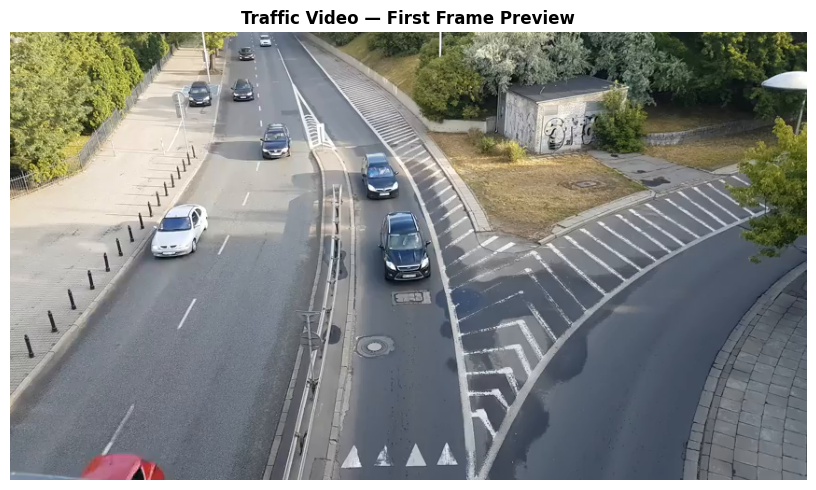

In [2]:
# Cell 2: Download Traffic Video from YouTube

!pip install yt-dlp -q

import yt_dlp
import cv2
import matplotlib.pyplot as plt
import numpy as np

VIDEO_PATH = "traffic_video.mp4"

# --- Download short traffic video from YouTube ---
ydl_opts = {
    'format'    : 'bestvideo[ext=mp4][height<=480]+bestaudio[ext=m4a]/best[ext=mp4]/best',
    'outtmpl'   : VIDEO_PATH,
    'quiet'     : True,
    'no_warnings': True,
    # Download only first 30 seconds
    'postprocessor_args': ['-t', '30'],
    'external_downloader_args': ['-t', '30'],
}

# Short public traffic footage
url = "https://www.youtube.com/watch?v=MNn9qKG2UFI"

print("Downloading traffic video from YouTube...")
print("This may take 1-2 minutes...")

with yt_dlp.YoutubeDL(ydl_opts) as ydl:
    ydl.download([url])

print("Download complete ✓")

# --- Verify ---
cap      = cv2.VideoCapture(VIDEO_PATH)
fps      = cap.get(cv2.CAP_PROP_FPS)
width    = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height   = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
total    = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
duration = total / fps if fps > 0 else 0

print(f"\nVideo details:")
print(f"  Resolution : {width}x{height}")
print(f"  FPS        : {fps:.1f}")
print(f"  Frames     : {total}")
print(f"  Duration   : {duration:.1f} seconds")

# --- Show first frame ---
ret, frame = cap.read()
cap.release()

if ret:
    plt.figure(figsize=(10, 5))
    plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
    plt.title("Traffic Video — First Frame Preview", fontweight='bold')
    plt.axis('off')
    plt.tight_layout()
    plt.show()


# Load YOLOv8 + Setup Parameters

In [3]:
# Load YOLOv8 Model & Setup All Parameters

# --- Load YOLOv8 -
model_yolo = YOLO("yolov8n.pt")
print("YOLOv8 Nano loaded ✓")

# --- Video parameters ---
cap       = cv2.VideoCapture(VIDEO_PATH)
FPS       = cap.get(cv2.CAP_PROP_FPS)
WIDTH     = 768
HEIGHT    = 432
if FPS == 0:
    FPS = 12.5
cap.release()

# --- Vehicle class IDs (COCO dataset) ---
VEHICLE_CLASSES = {
    2  : "Car",
    3  : "Motorcycle",
    5  : "Bus",
    7  : "Truck"
}

# --- Traffic thresholds ---
LOW_SPEED_THRESHOLD = 20   # pixels/frame — below this = slow vehicle
MIN_VEHICLES        = 5    # min vehicles to check congestion
MIN_LOW_SPEED       = 3    # min slow vehicles for congestion
CONGESTION_FRAMES   = 20   # consecutive frames to confirm congestion

# --- Memory dictionaries ---
prev_positions  = {}       # last known position per vehicle
speed_memory    = {}       # current speed per vehicle
speed_history   = {}       # speed history for smoothing
last_seen       = {}       # frames since last seen
vehicle_log     = []       # for analytics charts
MAX_MISSING     = 30       # frames before vehicle removed

# --- Counters ---
congestion_counter = 0
frame_count        = 0

print("\nConfiguration:")
print(f"  Resolution         : {WIDTH}x{HEIGHT}")
print(f"  FPS                : {FPS}")
print(f"  Vehicle classes    : {list(VEHICLE_CLASSES.values())}")
print(f"  Low speed threshold: {LOW_SPEED_THRESHOLD} px/frame")
print(f"  Congestion trigger : {MIN_VEHICLES} vehicles + "
      f"{MIN_LOW_SPEED} slow for {CONGESTION_FRAMES} frames")
print(f"\nAll parameters configured ✓")


YOLOv8 Nano loaded ✓

Configuration:
  Resolution         : 768x432
  FPS                : 30.0
  Vehicle classes    : ['Car', 'Motorcycle', 'Bus', 'Truck']
  Low speed threshold: 20 px/frame
  Congestion trigger : 5 vehicles + 3 slow for 20 frames

All parameters configured ✓


# Main Processing Loop (Detection + Tracking + Speed + Congestion)

In [4]:
#  Main Video Processing Loop
# Detection + Tracking + Speed + Congestion + Save Output Video

cap    = cv2.VideoCapture(VIDEO_PATH)
fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out    = cv2.VideoWriter('output_traffic.mp4', fourcc, FPS, (WIDTH, HEIGHT))

frame_count        = 0
congestion_counter = 0
prev_positions     = {}
speed_memory       = {}
speed_history      = {}
last_seen          = {}
vehicle_log        = []

print("Processing video... please wait")
print("="*50)

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    frame      = cv2.resize(frame, (WIDTH, HEIGHT))
    frame_count += 1

    # --- YOLOv8 Detection + Tracking ---
    results = model_yolo.track(
        frame, persist=True,
        conf=0.3, iou=0.5, verbose=False
    )

    vehicle_count  = 0
    low_speed_count = 0

    if results[0].boxes is not None and results[0].boxes.id is not None:
        boxes  = results[0].boxes.xyxy.cpu().numpy()
        ids    = results[0].boxes.id.cpu().numpy()
        clss   = results[0].boxes.cls.cpu().numpy()

        current_ids = set()

        for box, track_id, cls in zip(boxes, ids, clss):
            if int(cls) not in VEHICLE_CLASSES:
                continue

            x1, y1, x2, y2 = map(int, box)
            cx = int((x1 + x2) / 2)
            cy = int((y1 + y2) / 2)
            label = VEHICLE_CLASSES[int(cls)]

            current_ids.add(track_id)
            last_seen[track_id] = 0

            # --- Speed calculation ---
            if track_id in prev_positions:
                px, py = prev_positions[track_id]
                distance = np.sqrt((cx-px)**2 + (cy-py)**2)
                instant_speed = distance * FPS

                if track_id not in speed_history:
                    speed_history[track_id] = []
                speed_history[track_id].append(instant_speed)
                if len(speed_history[track_id]) > 5:
                    speed_history[track_id].pop(0)

                speed = sum(speed_history[track_id]) / len(speed_history[track_id])
                speed_memory[track_id] = speed
            else:
                speed_memory[track_id] = 0

            prev_positions[track_id] = (cx, cy)
            vehicle_count += 1

            spd = int(speed_memory[track_id])
            if spd < LOW_SPEED_THRESHOLD:
                low_speed_count += 1

            # --- Color by speed ---
            color = (0, 255, 0) if spd >= LOW_SPEED_THRESHOLD else (0, 0, 255)

            # --- Draw bounding box ---
            cv2.rectangle(frame, (x1,y1), (x2,y2), color, 2)
            cv2.putText(frame, f"{label} ID:{int(track_id)}",
                        (x1, y1-10),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.45, color, 2)
            cv2.putText(frame, f"Spd:{spd}",
                        (x1, y2+15),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.45, (255,255,0), 2)

        # --- Remove lost vehicles ---
        for tid in list(last_seen.keys()):
            if tid not in current_ids:
                last_seen[tid] += 1
                if last_seen[tid] > MAX_MISSING:
                    for d in [last_seen, prev_positions,
                               speed_memory, speed_history]:
                        d.pop(tid, None)

    # --- Congestion detection ---
    if vehicle_count >= MIN_VEHICLES and low_speed_count >= MIN_LOW_SPEED:
        congestion_counter += 1
    else:
        congestion_counter = max(0, congestion_counter - 1)

    is_congested = congestion_counter >= CONGESTION_FRAMES

    # --- Traffic level ---
    if vehicle_count < 3:
        level = "FREE FLOW"
        level_color = (0, 255, 0)
    elif vehicle_count < 8:
        level = "MODERATE"
        level_color = (0, 255, 255)
    else:
        level = "HEAVY"
        level_color = (0, 165, 255)

    # --- Draw HUD ---
    cv2.rectangle(frame, (0,0), (220, 110), (0,0,0), -1)

    if is_congested:
        cv2.putText(frame, "!! CONGESTION !!",
                    (50, 145), cv2.FONT_HERSHEY_SIMPLEX,
                    0.8, (0,0,255), 2)

    cv2.putText(frame, f"Vehicles : {vehicle_count}",
                (10,25), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255,255,255), 2)
    cv2.putText(frame, f"Slow     : {low_speed_count}",
                (10,50), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255,255,255), 2)
    cv2.putText(frame, f"Status   : {level}",
                (10,75), cv2.FONT_HERSHEY_SIMPLEX, 0.6, level_color, 2)
    cv2.putText(frame, f"Frame    : {frame_count}",
                (10,100), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (200,200,200), 2)

    # --- Log for analytics ---
    vehicle_log.append({
        'frame'        : frame_count,
        'vehicle_count': vehicle_count,
        'low_speed'    : low_speed_count,
        'level'        : level,
        'congested'    : is_congested,
        'avg_speed'    : np.mean(list(speed_memory.values())) if speed_memory else 0
    })

    out.write(frame)

    # --- Show every 30th frame ---
    if frame_count % 30 == 0:
        print(f"  Frame {frame_count:3d} | Vehicles: {vehicle_count} "
              f"| Slow: {low_speed_count} | {level}")

cap.release()
out.release()

print("="*50)
print(f"Processing complete ✓")
print(f"Total frames processed : {frame_count}")
print(f"Output saved           : output_traffic.mp4")


Processing video... please wait
requirements: Ultralytics requirement ['lap>=0.5.12'] not found, attempting AutoUpdate...
Using Python 3.12.13 environment at: /usr
Resolved 2 packages in 518ms
Prepared 1 package in 4.96s
Installed 1 package in 2ms
 + lap==0.5.13

requirements: AutoUpdate success ✅ 6.2s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect

  Frame  30 | Vehicles: 5 | Slow: 1 | MODERATE
  Frame  60 | Vehicles: 7 | Slow: 2 | MODERATE
  Frame  90 | Vehicles: 4 | Slow: 1 | MODERATE
  Frame 120 | Vehicles: 3 | Slow: 1 | MODERATE
  Frame 150 | Vehicles: 6 | Slow: 1 | MODERATE
  Frame 180 | Vehicles: 6 | Slow: 1 | MODERATE
  Frame 210 | Vehicles: 8 | Slow: 1 | HEAVY
  Frame 240 | Vehicles: 8 | Slow: 2 | HEAVY
  Frame 270 | Vehicles: 10 | Slow: 3 | HEAVY
  Frame 300 | Vehicles: 10 | Slow: 1 | HEAVY
  Frame 330 | Vehicles: 9 | Slow: 1 | HEAVY
  Frame 360 | Vehicles: 8 | Slow: 1 | HEAVY
  Frame 390 | Vehicles: 5 | Slow: 1 | MODERATE
  Frame 420 | V

# Video Analytics Charts

Video Analytics Report
  Total frames     : 901
  Duration         : 30.0 seconds
  Avg vehicles     : 7.1
  Max vehicles     : 13
  Avg speed        : 97.2 px/frame
  Congested frames : 0


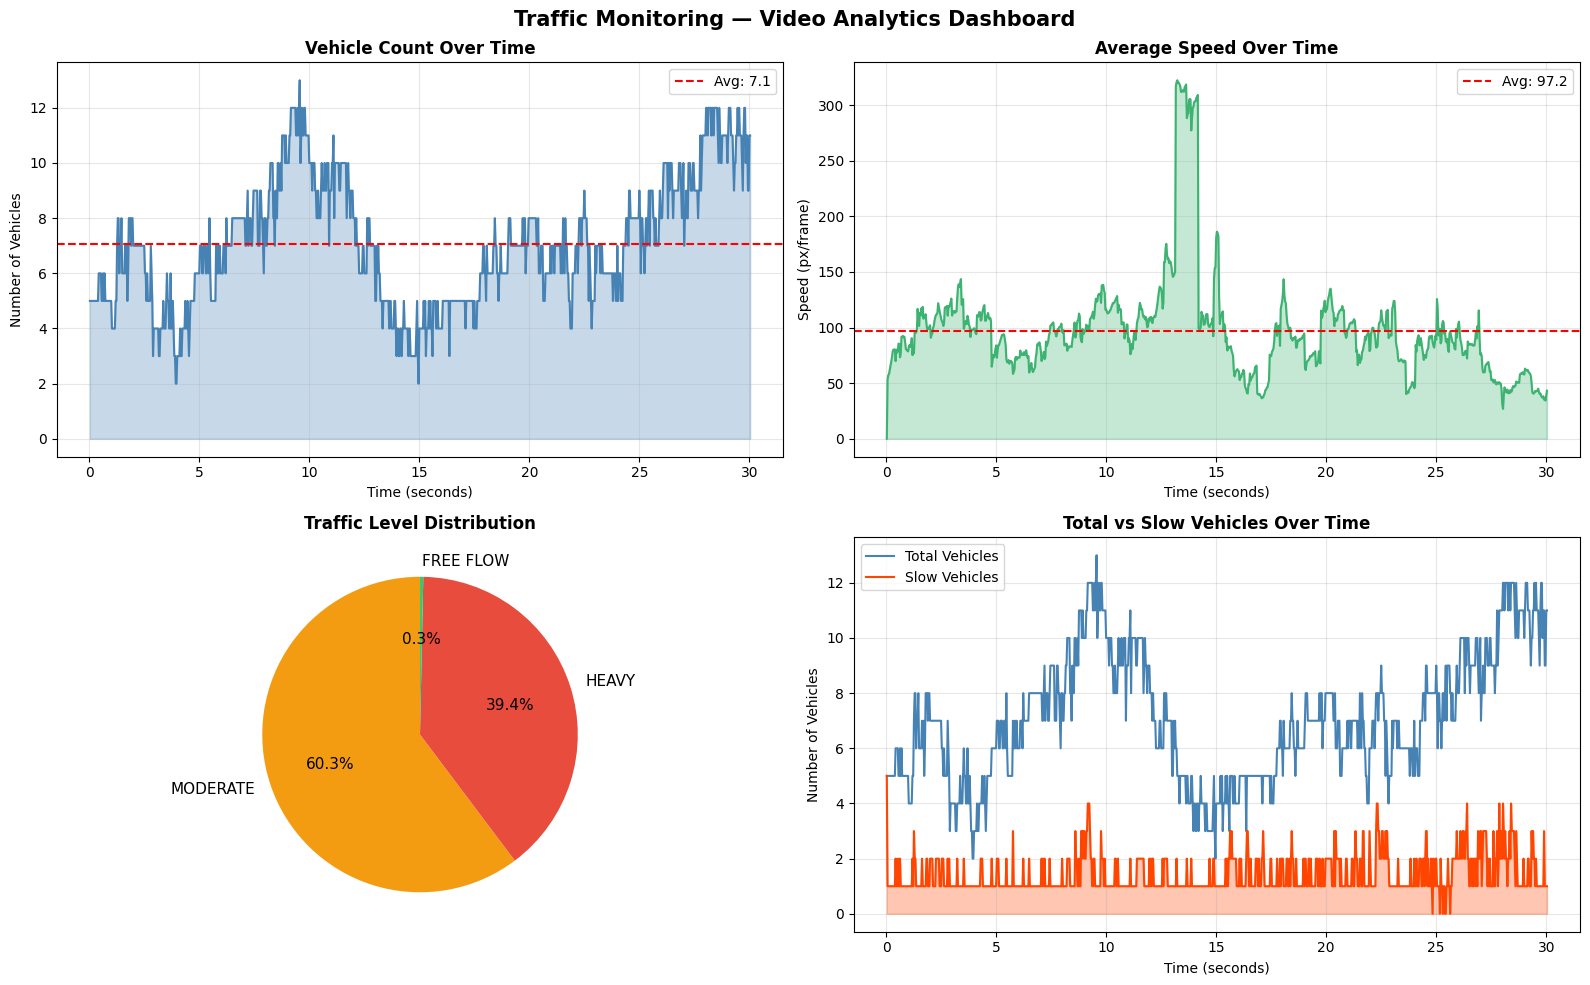

Analytics dashboard saved ✓


In [5]:
# Video Analytics - Charts & Statistics

import pandas as pd

# --- Convert log to dataframe ---
df = pd.DataFrame(vehicle_log)
df['time_sec'] = df['frame'] / FPS

print("Video Analytics Report")
print("="*50)
print(f"  Total frames     : {len(df)}")
print(f"  Duration         : {df['time_sec'].max():.1f} seconds")
print(f"  Avg vehicles     : {df['vehicle_count'].mean():.1f}")
print(f"  Max vehicles     : {df['vehicle_count'].max()}")
print(f"  Avg speed        : {df['avg_speed'].mean():.1f} px/frame")
print(f"  Congested frames : {df['congested'].sum()}")
print("="*50)

# --- Traffic level counts ---
level_counts = df['level'].value_counts()

# ============================================
# PLOT 1: Vehicle Count Over Time
# ============================================
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

axes[0,0].plot(df['time_sec'], df['vehicle_count'],
               color='steelblue', linewidth=1.5)
axes[0,0].fill_between(df['time_sec'], df['vehicle_count'],
                        alpha=0.3, color='steelblue')
axes[0,0].axhline(df['vehicle_count'].mean(), color='red',
                   linestyle='--', label=f"Avg: {df['vehicle_count'].mean():.1f}")
axes[0,0].set_title('Vehicle Count Over Time', fontweight='bold', fontsize=12)
axes[0,0].set_xlabel('Time (seconds)')
axes[0,0].set_ylabel('Number of Vehicles')
axes[0,0].legend()
axes[0,0].grid(True, alpha=0.3)

# ============================================
# PLOT 2: Average Speed Over Time
# ============================================
axes[0,1].plot(df['time_sec'], df['avg_speed'],
               color='mediumseagreen', linewidth=1.5)
axes[0,1].fill_between(df['time_sec'], df['avg_speed'],
                        alpha=0.3, color='mediumseagreen')
axes[0,1].axhline(df['avg_speed'].mean(), color='red',
                   linestyle='--',
                   label=f"Avg: {df['avg_speed'].mean():.1f}")
axes[0,1].set_title('Average Speed Over Time', fontweight='bold', fontsize=12)
axes[0,1].set_xlabel('Time (seconds)')
axes[0,1].set_ylabel('Speed (px/frame)')
axes[0,1].legend()
axes[0,1].grid(True, alpha=0.3)

# ============================================
# PLOT 3: Traffic Level Distribution (Pie)
# ============================================
colors_pie = {'FREE FLOW':'#2ecc71', 'MODERATE':'#f39c12', 'HEAVY':'#e74c3c'}
pie_colors = [colors_pie.get(l, 'gray') for l in level_counts.index]

axes[1,0].pie(level_counts.values,
              labels=level_counts.index,
              colors=pie_colors,
              autopct='%1.1f%%',
              startangle=90,
              textprops={'fontsize':11})
axes[1,0].set_title('Traffic Level Distribution',
                     fontweight='bold', fontsize=12)

# ============================================
# PLOT 4: Slow vs Total Vehicles Over Time
# ============================================
axes[1,1].plot(df['time_sec'], df['vehicle_count'],
               color='steelblue', linewidth=1.5, label='Total Vehicles')
axes[1,1].plot(df['time_sec'], df['low_speed'],
               color='orangered', linewidth=1.5, label='Slow Vehicles')
axes[1,1].fill_between(df['time_sec'], df['low_speed'],
                        alpha=0.3, color='orangered')

# Mark congested periods
congested = df[df['congested'] == True]
if len(congested) > 0:
    axes[1,1].scatter(congested['time_sec'],
                      congested['vehicle_count'],
                      color='red', s=10, zorder=5,
                      label='Congestion Detected')

axes[1,1].set_title('Total vs Slow Vehicles Over Time',
                     fontweight='bold', fontsize=12)
axes[1,1].set_xlabel('Time (seconds)')
axes[1,1].set_ylabel('Number of Vehicles')
axes[1,1].legend()
axes[1,1].grid(True, alpha=0.3)

plt.suptitle('Traffic Monitoring — Video Analytics Dashboard',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('traffic_analytics.png', dpi=150, bbox_inches='tight')
plt.show()

print("Analytics dashboard saved ✓")

# Sample Frames + Final Summary

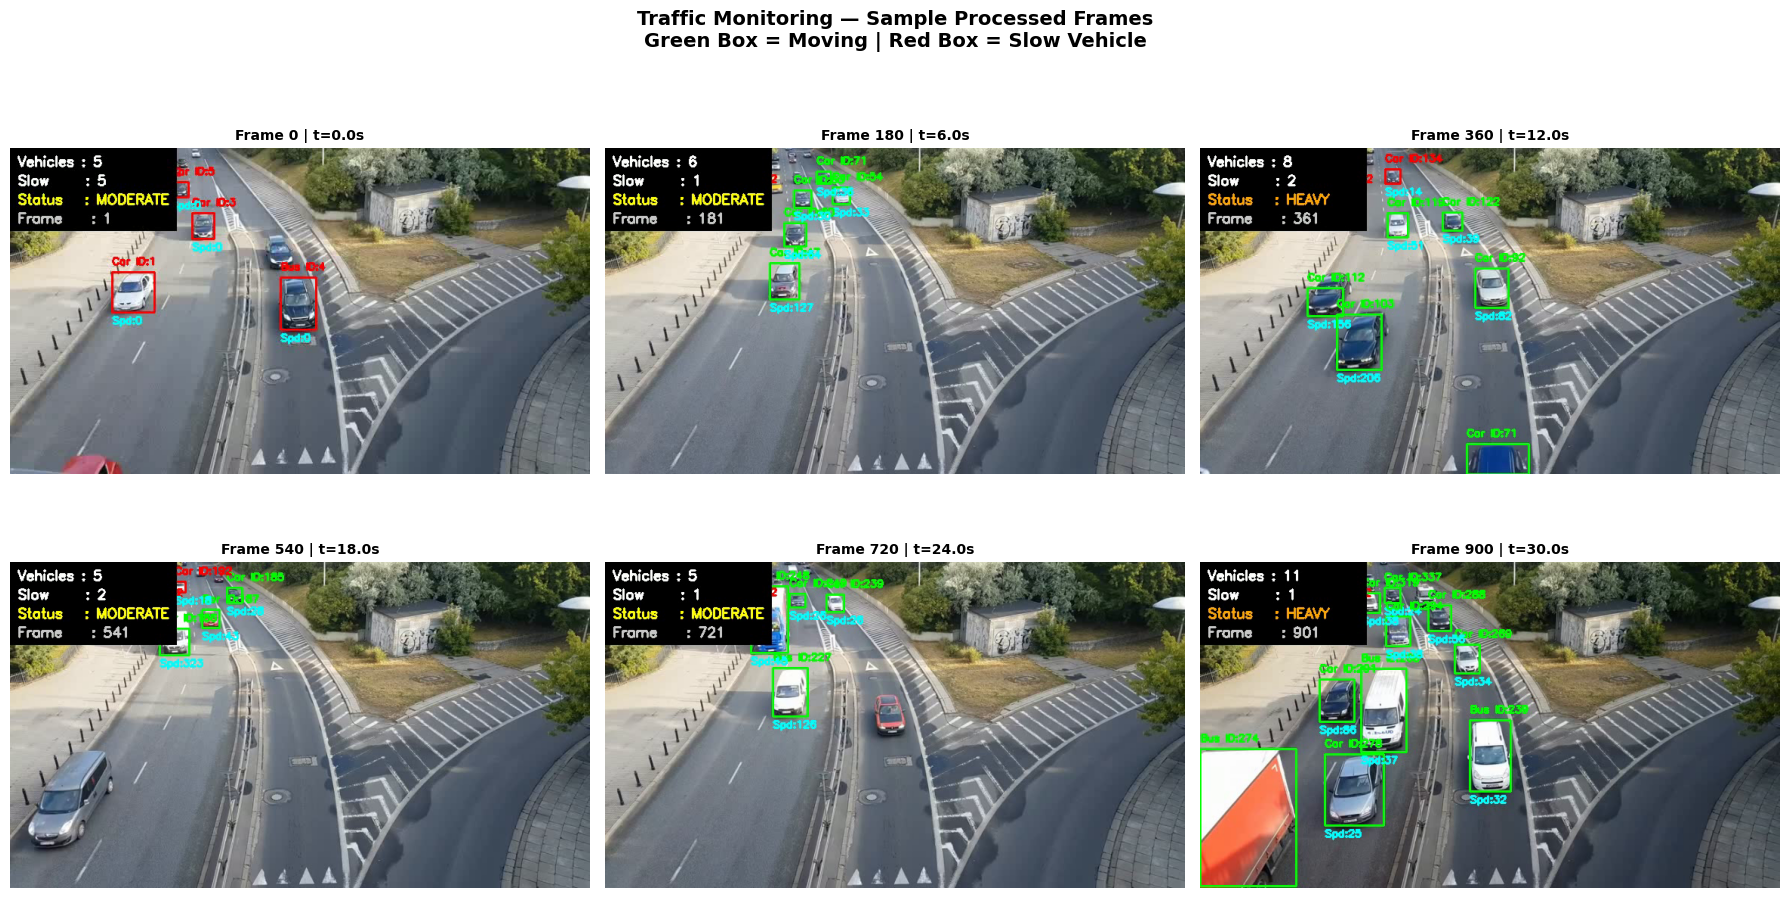

Sample frames saved ✓

╔══════════════════════════════════════════════════════════╗
║    TRAFFIC MONITORING & VIDEO ANALYTICS — SUMMARY        ║
╚══════════════════════════════════════════════════════════╝

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 VIDEO DETAILS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Total frames processed : 901
  Video duration         : 30.0 seconds
  Model used             : YOLOv8 Nano

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 VEHICLE STATISTICS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Avg vehicles per frame : 7.1
  Max vehicles detected  : 13
  Avg speed              : 97.2 px/frame
  Vehicle classes        : Car, Motorcycle, Bus, Truck

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 TRAFFIC ANALYSIS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  FREE FLOW  :    3 frames (0.3%)
  MODERATE   :  543 frames (60.3%)
  HEAVY      :  355 frames (39.4%)
  Congestion :    0

In [6]:
#  Show Sample Processed Frames + Final Summary

# --- Extract 6 sample frames from output video ---
cap_out = cv2.VideoCapture('output_traffic.mp4')
total_frames = int(cap_out.get(cv2.CAP_PROP_FRAME_COUNT))

# Pick 6 evenly spaced frames
sample_indices = np.linspace(0, total_frames-1, 6, dtype=int)
sample_frames  = []

for idx in sample_indices:
    cap_out.set(cv2.CAP_PROP_POS_FRAMES, idx)
    ret, frame = cap_out.read()
    if ret:
        sample_frames.append((idx, frame))

cap_out.release()

# --- Display sample frames ---
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for ax, (idx, frame) in zip(axes.flatten(), sample_frames):
    ax.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
    ax.set_title(f"Frame {idx} | "
                 f"t={idx/FPS:.1f}s",
                 fontweight='bold', fontsize=10)
    ax.axis('off')

plt.suptitle('Traffic Monitoring — Sample Processed Frames\n'
             'Green Box = Moving | Red Box = Slow Vehicle',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('sample_frames.png', dpi=150, bbox_inches='tight')
plt.show()
print("Sample frames saved ✓")

# --- Final Summary ---
level_counts = df['level'].value_counts()

print(f"""
╔══════════════════════════════════════════════════════════╗
║    TRAFFIC MONITORING & VIDEO ANALYTICS — SUMMARY        ║
╚══════════════════════════════════════════════════════════╝

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 VIDEO DETAILS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Total frames processed : {len(df)}
  Video duration         : {df['time_sec'].max():.1f} seconds
  Model used             : YOLOv8 Nano

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 VEHICLE STATISTICS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Avg vehicles per frame : {df['vehicle_count'].mean():.1f}
  Max vehicles detected  : {df['vehicle_count'].max()}
  Avg speed              : {df['avg_speed'].mean():.1f} px/frame
  Vehicle classes        : Car, Motorcycle, Bus, Truck

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 TRAFFIC ANALYSIS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  FREE FLOW  : {level_counts.get('FREE FLOW',  0):4d} frames ({level_counts.get('FREE FLOW',  0)/len(df)*100:.1f}%)
  MODERATE   : {level_counts.get('MODERATE',   0):4d} frames ({level_counts.get('MODERATE',   0)/len(df)*100:.1f}%)
  HEAVY      : {level_counts.get('HEAVY',      0):4d} frames ({level_counts.get('HEAVY',      0)/len(df)*100:.1f}%)
  Congestion : {df['congested'].sum():4d} frames detected

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 FILES SAVED
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  📁 output_traffic.mp4      (processed video)
  📁 traffic_analytics.png   (analytics dashboard)
  📁 sample_frames.png       (sample detections)

══════════════════════════════════════════════════════════
  ✅ Traffic Monitoring & Video Analytics COMPLETE!
══════════════════════════════════════════════════════════
""")